Figure saved to: ./figs/ornsteinUhlenbeck/vanillaOU.png


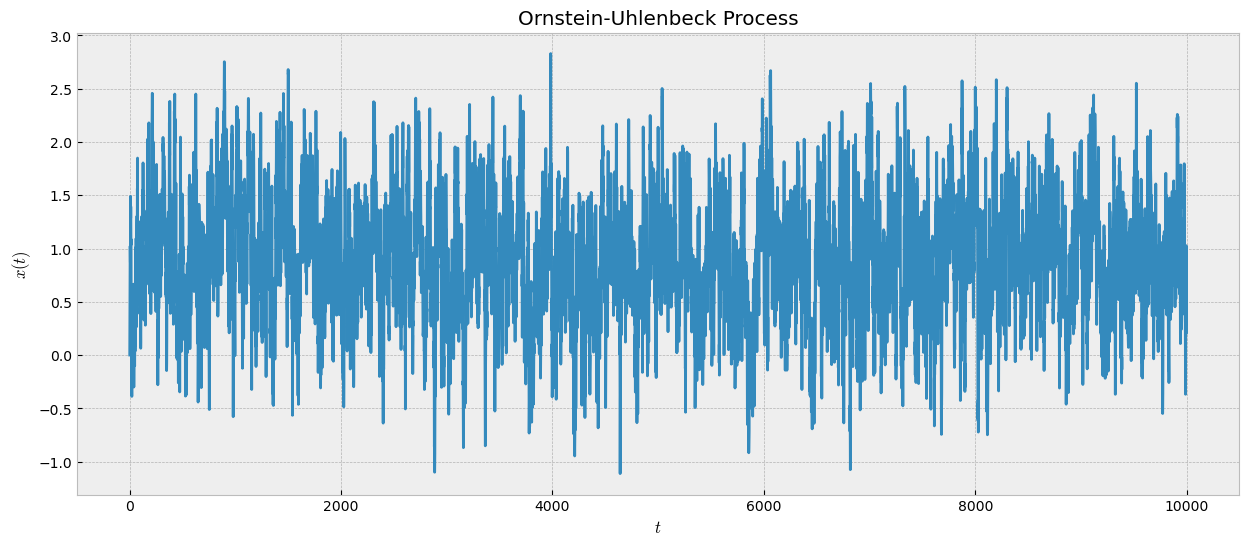

In [53]:
#!/usr/bin/env python3

import numpy as np
import matplotlib.pyplot as plt
import os

# Set plotting style
plt.style.use("bmh")

def generate_process(dt=0.1, theta=1.2, mu=0.9, sigma=0.9, n=10000):
    """
    Generate an Ornstein-Uhlenbeck process time series.
    
    Parameters:
    -----------
    dt : float
        Time step size
    theta : float
        Mean reversion speed (how quickly the process reverts to mean)
    mu : float
        Mean value (long-term mean to which the process tends to revert)
    sigma : float
        Volatility or scale of the random fluctuations
    n : int
        Number of time steps to simulate
    
    Returns:
    --------
    x : numpy.ndarray
        Array containing the simulated Ornstein-Uhlenbeck process
    """
    # Initialize array to store the process values
    x = np.zeros(n)
    
    # Generate the process using the Euler-Maruyama method
    for t in range(1, n):
        # Fixed formula: dx = theta * (mu - x) * dt + sigma * dW
        # where dW is a Wiener process increment (normal distribution with mean 0 and variance dt)
        x[t] = x[t-1] + theta * (mu - x[t-1]) * dt + sigma * np.random.normal(0, np.sqrt(dt))
    
    return x

def plot_process(x, save_path=None):
    """
    Plot the Ornstein-Uhlenbeck process and optionally save the figure.
    
    Parameters:
    -----------
    x : numpy.ndarray
        Array containing the Ornstein-Uhlenbeck process to plot
    save_path : str, optional
        Path where the figure should be saved. If None, figure is not saved.
    """
    plt.figure(figsize=(15, 6))
    plt.plot(x)
    plt.xlabel(r"$t$")
    plt.ylabel(r"$x(t)$")
    plt.title("Ornstein-Uhlenbeck Process")
    
    # Save figure if a path is provided
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
if __name__ == "__main__":
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Generate the Ornstein-Uhlenbeck process
    data = generate_process()
    
    # Define the save path
    save_path = "./figs/ornsteinUhlenbeck/vanillaOU.png"
    
    # Plot and save the process
    plot_process(data, save_path)